In [5]:
!pip -q install pandas scikit-learn matplotlib nltk tabulate

In [6]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tabulate import tabulate

nltk.download('punkt')
nltk.download('stopwords')

print("All libraries imported successfully.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
data = {
    "Candidate": [
        "Rahul",
        "Priya",
        "Amit",
        "Sneha",
        "Rohan",
        "Anjali",
        "Arjun",
        "Neha",
        "Vikas",
        "Pooja"
    ],

    "Resume": [

        "Python SQL Machine Learning Data Analysis Artificial Intelligence Excel",

        "Java Spring Boot HTML CSS JavaScript MySQL",

        "Python Data Science Deep Learning TensorFlow SQL Power BI",

        "C C++ Data Structures Algorithms Python SQL",

        "HTML CSS JavaScript React Node MongoDB",

        "Python Machine Learning NLP Deep Learning Artificial Intelligence",

        "Java Python SQL Cloud AWS Docker",

        "Python Tableau SQL Excel Statistics",

        "Networking Linux Cyber Security Python",

        "Python Machine Learning SQL Data Visualization Pandas Numpy"
    ]
}

resume_df = pd.DataFrame(data)

resume_df

,Candidate,Resume
0,Rahul,Python SQL Machine Learning Data Analysis Arti...
1,Priya,Java Spring Boot HTML CSS JavaScript MySQL
2,Amit,Python Data Science Deep Learning TensorFlow S...
3,Sneha,C C++ Data Structures Algorithms Python SQL
4,Rohan,HTML CSS JavaScript React Node MongoDB
5,Anjali,Python Machine Learning NLP Deep Learning Arti...
6,Arjun,Java Python SQL Cloud AWS Docker
7,Neha,Python Tableau SQL Excel Statistics
8,Vikas,Networking Linux Cyber Security Python
9,Pooja,Python Machine Learning SQL Data Visualization...


In [8]:
job_description = """
Looking for a Python Developer having knowledge of
Machine Learning,
Artificial Intelligence,
SQL,
Data Analysis,
Pandas,
NumPy,
Deep Learning,
NLP,
and Data Visualization.
"""

print(job_description)


Looking for a Python Developer having knowledge of
Machine Learning,
Artificial Intelligence,
SQL,
Data Analysis,
Pandas,
NumPy,
Deep Learning,
NLP,
and Data Visualization.



In [9]:
documents = [job_description] + resume_df["Resume"].tolist()

vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

print("\nData preprocessing completed successfully.")

TF-IDF Matrix Shape: (11, 43)

Data preprocessing completed successfully.


In [16]:

similarity_scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

resume_df["Match Score"] = similarity_scores * 100

ranked_df = resume_df.sort_values(
    by="Match Score",
    ascending=False
).reset_index(drop=True)

print(ranked_df)

  Candidate                                             Resume  Match Score
0     Pooja  Python Machine Learning SQL Data Visualization...    64.168043
1    Anjali  Python Machine Learning NLP Deep Learning Arti...    58.622957
2     Rahul  Python SQL Machine Learning Data Analysis Arti...    56.603260
3      Amit  Python Data Science Deep Learning TensorFlow S...    28.409419
4     Sneha        C C++ Data Structures Algorithms Python SQL    19.235500
5      Neha                Python Tableau SQL Excel Statistics     6.704009
6     Arjun                   Java Python SQL Cloud AWS Docker     5.843701
7     Vikas             Networking Linux Cyber Security Python     2.417049
8     Priya         Java Spring Boot HTML CSS JavaScript MySQL     0.000000
9     Rohan             HTML CSS JavaScript React Node MongoDB     0.000000


In [18]:


ranked_df = resume_df.sort_values(
    by="Match Score",
    ascending=False
).reset_index(drop=True)

ranked_df.index = ranked_df.index + 1

print("\n========= Resume Ranking =========\n")

print(tabulate(
    ranked_df,
    headers="keys",
    tablefmt="pretty",
    showindex=True
))


========= Resume Ranking =========

+----+-----------+-------------------------------------------------------------------------+--------------------+
|    | Candidate |                                 Resume                                  |    Match Score     |
+----+-----------+-------------------------------------------------------------------------+--------------------+
| 1  |   Pooja   |       Python Machine Learning SQL Data Visualization Pandas Numpy       | 64.16804256312018  |
| 2  |  Anjali   |    Python Machine Learning NLP Deep Learning Artificial Intelligence    | 58.62295680698186  |
| 3  |   Rahul   | Python SQL Machine Learning Data Analysis Artificial Intelligence Excel |  56.6032602489118  |
| 4  |   Amit    |        Python Data Science Deep Learning TensorFlow SQL Power BI        | 28.409419288258537 |
| 5  |   Sneha   |               C C++ Data Structures Algorithms Python SQL               | 19.23549963050305  |
| 6  |   Neha    |                   Python Tableau

In [19]:
best = ranked_df.iloc[0]

print("="*50)
print("BEST CANDIDATE SELECTED BY AI")
print("="*50)

print("Candidate Name :", best["Candidate"])
print("Resume Match   :", round(best["Match Score"],2), "%")
print("="*50)

BEST CANDIDATE SELECTED BY AI
Candidate Name : Pooja
Resume Match   : 64.17 %


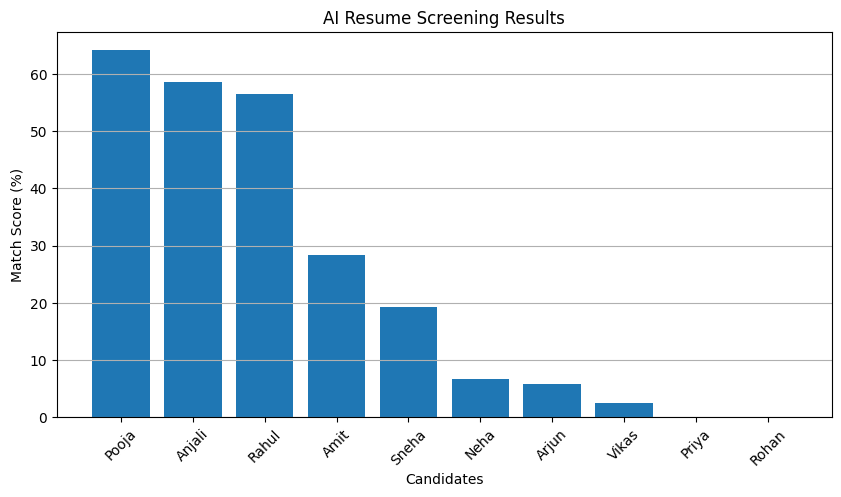

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    ranked_df["Candidate"],
    ranked_df["Match Score"]
)

plt.title("AI Resume Screening Results")
plt.xlabel("Candidates")
plt.ylabel("Match Score (%)")

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

In [17]:
print("="*60)
print("AI HIRING RECOMMENDATION")
print("="*60)

for i in range(len(ranked_df)):

    score = ranked_df.loc[i,"Match Score"]

    if score >= 80:
        status = "Highly Recommended"

    elif score >= 60:
        status = "Recommended"

    elif score >= 40:
        status = "Consider"

    else:
        status = "Not Recommended"

    print(f"{ranked_df.loc[i,'Candidate']} --> {round(score,2)}% --> {status}")

print("="*60)

AI HIRING RECOMMENDATION
Pooja --> 64.17% --> Recommended
Anjali --> 58.62% --> Consider
Rahul --> 56.6% --> Consider
Amit --> 28.41% --> Not Recommended
Sneha --> 19.24% --> Not Recommended
Neha --> 6.7% --> Not Recommended
Arjun --> 5.84% --> Not Recommended
Vikas --> 2.42% --> Not Recommended
Priya --> 0.0% --> Not Recommended
Rohan --> 0.0% --> Not Recommended


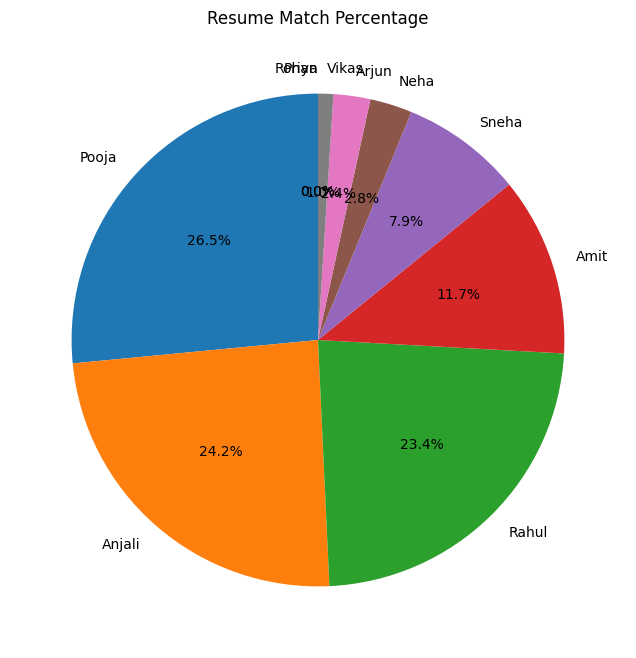

In [21]:
plt.figure(figsize=(8,8))

plt.pie(
    ranked_df["Match Score"],
    labels=ranked_df["Candidate"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Resume Match Percentage")

plt.show()

In [22]:
skills = [
    "Python","Java","SQL","Machine Learning","Deep Learning",
    "Artificial Intelligence","NLP","Pandas","NumPy",
    "Excel","Power BI","Tableau","AWS","Docker",
    "React","Node","MongoDB","HTML","CSS","JavaScript"
]

best_resume = best["Resume"]

found_skills = []

for skill in skills:
    if skill.lower() in best_resume.lower():
        found_skills.append(skill)

print("Skills Found in Best Candidate:\n")

for s in found_skills:
    print("✔", s)

Skills Found in Best Candidate:

✔ Python
✔ SQL
✔ Machine Learning
✔ Pandas
✔ NumPy


In [23]:
custom_job = input("Enter your own Job Description:\n")

documents = [custom_job] + resume_df["Resume"].tolist()

vectorizer = TfidfVectorizer(stop_words="english")

matrix = vectorizer.fit_transform(documents)

scores = cosine_similarity(matrix[0:1], matrix[1:]).flatten()

resume_df["Custom Match"] = scores * 100

custom_rank = resume_df.sort_values(
    by="Custom Match",
    ascending=False
)

print("\nTop Candidate")

print(custom_rank[["Candidate","Custom Match"]].head())

Enter your own Job Description:
Software engineer

Top Candidate
  Candidate  Custom Match
0     Rahul           0.0
1     Priya           0.0
2      Amit           0.0
3     Sneha           0.0
4     Rohan           0.0


In [24]:
name = input("Enter Candidate Name: ")

result = resume_df[
    resume_df["Candidate"].str.lower() == name.lower()
]

if len(result) == 0:
    print("Candidate Not Found")

else:
    print(result)

Enter Candidate Name: Priya
  Candidate                                      Resume  Match Score  \
1     Priya  Java Spring Boot HTML CSS JavaScript MySQL          0.0   

   Custom Match  
1           0.0  


In [26]:
print("="*60)
print("        AI RESUME SCREENING REPORT")
print("="*60)

print("\nTotal Candidates :", len(resume_df))

print("\nBest Candidate :", ranked_df.iloc[0]["Candidate"])

print("Match Score :", round(ranked_df.iloc[0]["Match Score"],2), "%")

print("\nTop 3 Candidates\n")

print(
    ranked_df[
        ["Candidate","Match Score"]
    ].head(3)
)

print("="*60)

        AI RESUME SCREENING REPORT

Total Candidates : 10

Best Candidate : Pooja
Match Score : 64.17 %

Top 3 Candidates

  Candidate  Match Score
1     Pooja    64.168043
2    Anjali    58.622957
3     Rahul    56.603260
